#1)Problem Statement

Loan approval is an important process for banks and financial institutions. Banks receive many loan applications every day, and it takes time to manually check whether a person is eligible for a loan or not. Because of this, there is a need for a system that can automatically predict whether a loan will be approved.

In this project, a Loan Prediction dataset is used to build a machine learning model that predicts the Loan_Status (Approved or Not Approved). The dataset is divided into two parts: train data and test data.

The training dataset contains information such as Loan_ID, Gender, Married, Dependents, Education, Self_Employed, ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term, Credit_History, Property_Area, and Loan_Status. This data is used to train the model.

The test dataset contains similar features but does not include the Loan_Status column. The trained model predicts the loan approval result for this test data.

The goal of this project is to develop a model that can accurately predict loan approval using the given applicant information.

#2)Import Libraries:

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

#3)Load Train Dataset:

In [2]:
dfloan=pd.read_csv("/content/train_u6lujuX_CVtuZ9i.csv")

In [3]:
dfloan

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [4]:
dfloan.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
dfloan.drop("Loan_ID",axis=1,inplace=True)

In [6]:
dfloan.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


#4)Handle Missing Values(NaNs):

In [8]:
dfloan.isna().sum()

,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50


In [9]:
dfloan.isna().sum().sum()

np.int64(149)

In [10]:
dfloan.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [11]:
nan_cols=["Gender","Married","Dependents","Self_Employed","Credit_History"]

In [12]:
nan_cols

['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']

In [13]:
for c in nan_cols:
  dfloan[c].fillna(dfloan[c].mode()[0],inplace=True)

/tmp/ipykernel_527/3838362926.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dfloan[c].fillna(dfloan[c].mode()[0],inplace=True)


In [14]:
dfloan["Loan_Amount_Term"].unique()

array([360., 120., 240.,  nan, 180.,  60., 300., 480.,  36.,  84.,  12.])

In [15]:
dfloan["Loan_Amount_Term"].value_counts()

,count
Loan_Amount_Term,
360.0,512
180.0,44
480.0,15
300.0,13
84.0,4
240.0,4
120.0,3
60.0,2
36.0,2


In [16]:
dfloan["Loan_Amount_Term"].isna().sum()

np.int64(14)

In [17]:
dfloan["Loan_Amount_Term"].fillna(dfloan["Loan_Amount_Term"].mode()[0],inplace=True)

/tmp/ipykernel_527/1684865728.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dfloan["Loan_Amount_Term"].fillna(dfloan["Loan_Amount_Term"].mode()[0],inplace=True)


In [18]:
dfloan["Loan_Amount_Term"].isna().sum()

np.int64(0)

In [19]:
dfloan.isna().sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,0
Credit_History,0


In [20]:
dfloan["LoanAmount"].isna().sum()

np.int64(22)

In [21]:
dfloan["LoanAmount"].unique()

array([ nan, 128.,  66., 120., 141., 267.,  95., 158., 168., 349.,  70.,
       109., 200., 114.,  17., 125., 100.,  76., 133., 115., 104., 315.,
       116., 112., 151., 191., 122., 110.,  35., 201.,  74., 106., 320.,
       144., 184.,  80.,  47.,  75., 134.,  96.,  88.,  44., 286.,  97.,
       135., 180.,  99., 165., 258., 126., 312., 136., 172.,  81., 187.,
       113., 176., 130., 111., 167., 265.,  50., 210., 175., 131., 188.,
        25., 137., 160., 225., 216.,  94., 139., 152., 118., 185., 154.,
        85., 259., 194.,  93., 370., 182., 650., 102., 290.,  84., 242.,
       129.,  30., 244., 600., 255.,  98., 275., 121.,  63., 700.,  87.,
       101., 495.,  67.,  73., 260., 108.,  58.,  48., 164., 170.,  83.,
        90., 166., 124.,  55.,  59., 127., 214., 240.,  72.,  60., 138.,
        42., 280., 140., 155., 123., 279., 192., 304., 330., 150., 207.,
       436.,  78.,  54.,  89., 143., 105., 132., 480.,  56., 159., 300.,
       376., 117.,  71., 490., 173.,  46., 228., 30

In [22]:
dfloan["LoanAmount"].nunique()

203

In [23]:
dfloan["LoanAmount"].mean().round()

np.float64(146.0)

In [24]:
dfloan["LoanAmount"].fillna(dfloan["LoanAmount"].mean().round(),inplace=True)

/tmp/ipykernel_527/3735262501.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dfloan["LoanAmount"].fillna(dfloan["LoanAmount"].mean().round(),inplace=True)


In [25]:
dfloan["LoanAmount"].isna().sum()

np.int64(0)

In [26]:
dfloan.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,146.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [27]:
#NaNs:
dfloan.isna().sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


#5)Remove Errors / Data Cleaning:

<Axes: >

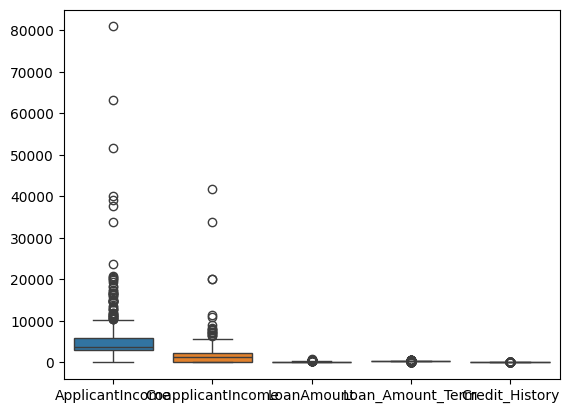

In [ ]:
sns.boxplot(dfloan)

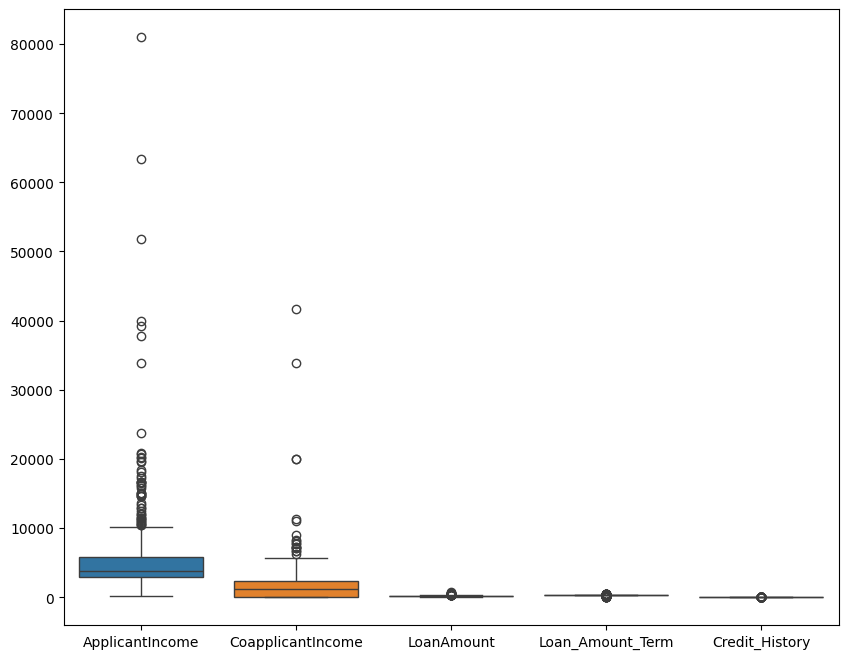

In [28]:
plt.figure(figsize=[10,8])
sns.boxplot(dfloan)
plt.show()

<Axes: ylabel='LoanAmount'>

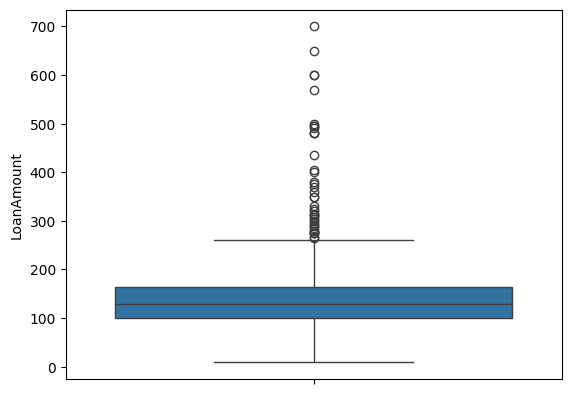

In [29]:
sns.boxplot(dfloan["LoanAmount"])

<Axes: ylabel='Loan_Amount_Term'>

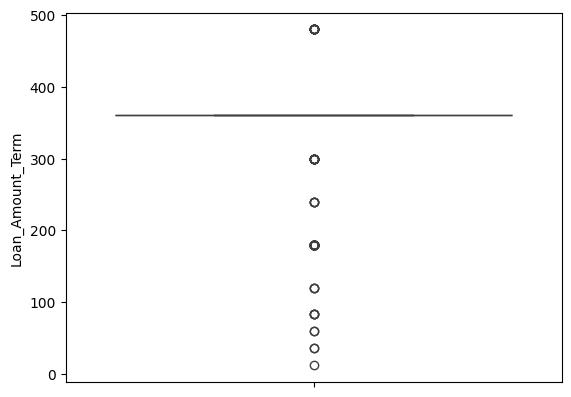

In [30]:
sns.boxplot(dfloan["Loan_Amount_Term"])

<Axes: ylabel='ApplicantIncome'>

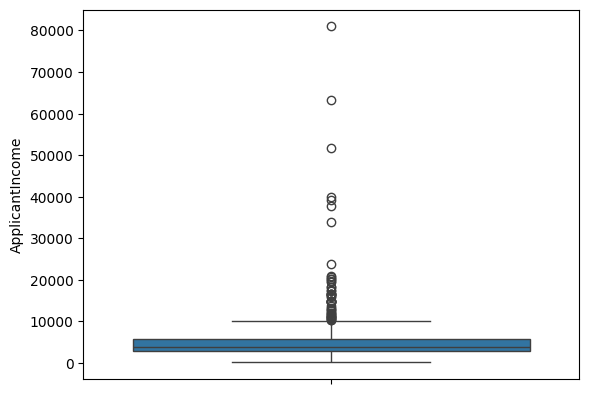

In [31]:
sns.boxplot(dfloan["ApplicantIncome"])

In [32]:
dfloan["CoapplicantIncome"].max()

41667.0

<Axes: ylabel='CoapplicantIncome'>

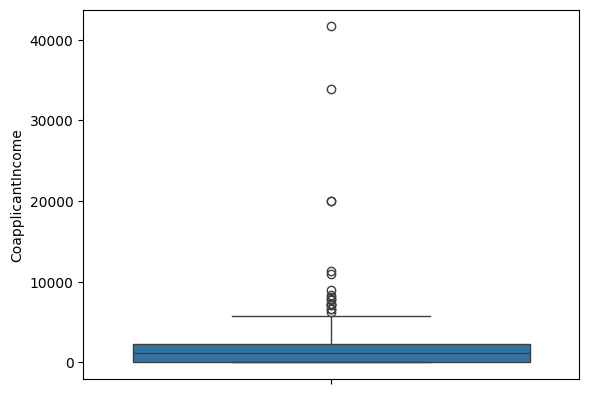

In [33]:
sns.boxplot(dfloan["CoapplicantIncome"])

In [34]:
dfloan["Credit_History"]

,Credit_History
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0
...,...
609,1.0
610,1.0
611,1.0
612,1.0


In [35]:
dfloan["Credit_History"].unique()

array([1., 0.])

In [36]:
dfloan["Credit_History"].value_counts()

,count
Credit_History,
1.0,525
0.0,89


In [37]:
dfloan["Loan_Amount_Term"].unique()

array([360., 120., 240., 180.,  60., 300., 480.,  36.,  84.,  12.])

In [38]:
dfloan["ApplicantIncome"].describe()

,ApplicantIncome
count,614.000000
mean,5403.459283
std,6109.041673
min,150.000000
25%,2877.500000
50%,3812.500000
75%,5795.000000
max,81000.000000


In [39]:
q1=dfloan["ApplicantIncome"].quantile(0.25)
q3=dfloan["ApplicantIncome"].quantile(0.75)
iqr=q3-q1
lower=q1-(1.5*iqr)
upper=q3+(1.5*iqr)

In [40]:
q1

np.float64(2877.5)

In [41]:
q3

np.float64(5795.0)

In [42]:
print(upper)

10171.25


In [43]:
dfloan

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,146.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


#6)Encodining Categorical Data:

In [44]:
dfloan.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,146.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


Label Encoding on Dependent Column

In [45]:
from sklearn.preprocessing import LabelEncoder

In [46]:
label=LabelEncoder()

In [47]:
label

LabelEncoder()

In [49]:
ary=label.fit_transform(dfloan["Loan_Status"])

In [50]:
ary

array([1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0,

In [51]:
dfloan["Loan_Status"]=ary

In [53]:
dfloan.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,146.0,360.0,1.0,Urban,1
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1


In [54]:
label.classes_

array(['N', 'Y'], dtype=object)

In [55]:
dfloan.dtypes

,0
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64
Credit_History,float64


In [56]:
from sklearn.preprocessing import OrdinalEncoder

In [57]:
olabel=OrdinalEncoder()

In [58]:
olabel

OrdinalEncoder()

In [59]:
dfloan["Dependents"].unique()

array(['0', '1', '2', '3+'], dtype=object)

In [60]:
dfloan["Dependents"]= olabel.fit_transform(dfloan[["Dependents"]]).astype(int)

In [61]:
dfloan["Dependents"]

,Dependents
0,0
1,1
2,0
3,0
4,0
...,...
609,0
610,3
611,1
612,2


In [62]:
dfloan=pd.get_dummies(dfloan,drop_first=True)

In [63]:
dfloan.replace([True,False],[1,0],inplace=True)

/tmp/ipykernel_527/312707027.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dfloan.replace([True,False],[1,0],inplace=True)


In [64]:
dfloan.head()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,5849,0.0,146.0,360.0,1.0,1,1,0,0,0,0,1
1,1,4583,1508.0,128.0,360.0,1.0,0,1,1,0,0,0,0
2,0,3000,0.0,66.0,360.0,1.0,1,1,1,0,1,0,1
3,0,2583,2358.0,120.0,360.0,1.0,1,1,1,1,0,0,1
4,0,6000,0.0,141.0,360.0,1.0,1,1,0,0,0,0,1


#7)Seperate feature and Target:

In [65]:
X=dfloan.drop("Loan_Status",axis=1)

In [66]:
X

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,5849,0.0,146.0,360.0,1.0,1,0,0,0,0,1
1,1,4583,1508.0,128.0,360.0,1.0,1,1,0,0,0,0
2,0,3000,0.0,66.0,360.0,1.0,1,1,0,1,0,1
3,0,2583,2358.0,120.0,360.0,1.0,1,1,1,0,0,1
4,0,6000,0.0,141.0,360.0,1.0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,2900,0.0,71.0,360.0,1.0,0,0,0,0,0,0
610,3,4106,0.0,40.0,180.0,1.0,1,1,0,0,0,0
611,1,8072,240.0,253.0,360.0,1.0,1,1,0,0,0,1
612,2,7583,0.0,187.0,360.0,1.0,1,1,0,0,0,1


In [67]:
X.shape

(614, 12)

In [68]:
y=dfloan["Loan_Status"]

In [69]:
y

,Loan_Status
0,1
1,0
2,1
3,1
4,1
...,...
609,1
610,1
611,1
612,1


In [70]:
y.shape

(614,)

#8)Data Imbalance:

In [71]:
dfloan.head()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,5849,0.0,146.0,360.0,1.0,1,1,0,0,0,0,1
1,1,4583,1508.0,128.0,360.0,1.0,0,1,1,0,0,0,0
2,0,3000,0.0,66.0,360.0,1.0,1,1,1,0,1,0,1
3,0,2583,2358.0,120.0,360.0,1.0,1,1,1,1,0,0,1
4,0,6000,0.0,141.0,360.0,1.0,1,1,0,0,0,0,1


In [72]:
dfloan["Loan_Status"].value_counts()

,count
Loan_Status,
1,422
0,192


<Axes: xlabel='Loan_Status'>

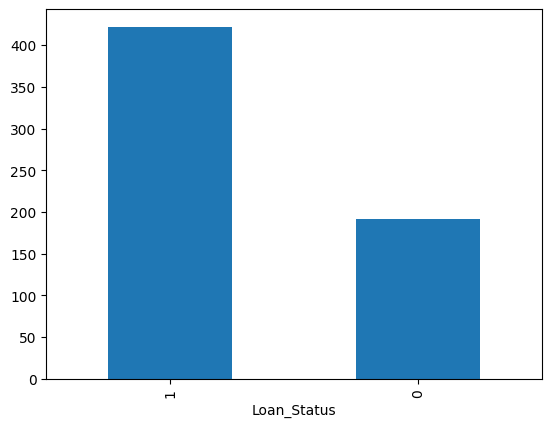

In [73]:
y.value_counts().plot(kind="bar")

In [75]:
from imblearn.over_sampling import SMOTE,RandomOverSampler

In [76]:
ros=RandomOverSampler()

In [77]:
ros

RandomOverSampler()

In [78]:
x_ros,y_ros=ros.fit_resample(X,y)

In [79]:
X.shape

(614, 12)

In [80]:
x_ros.shape

(844, 12)

In [81]:
y.shape

(614,)

In [82]:
y_ros.shape

(844,)

In [83]:
y.value_counts()

,count
Loan_Status,
1,422
0,192


In [84]:
y_ros.value_counts()

,count
Loan_Status,
1,422
0,422


<Axes: xlabel='Loan_Status'>

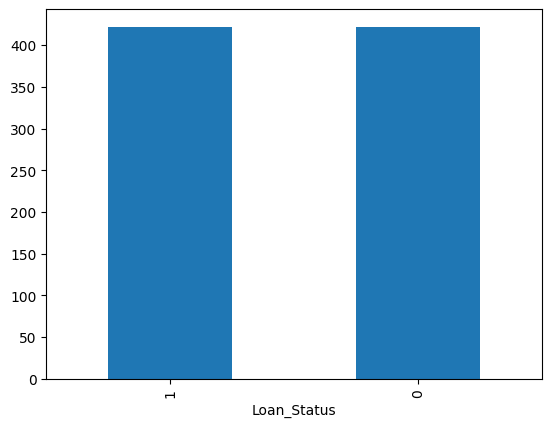

In [85]:
y_ros.value_counts().plot(kind="bar")

#9)Train Test Split:

In [86]:
from sklearn.model_selection import train_test_split

In [87]:
x_train,x_test,y_train,y_test=train_test_split(x_ros,y_ros,test_size=0.20,random_state=665)

In [88]:
x_train.shape

(675, 12)

In [89]:
x_test.shape

(169, 12)

In [90]:
x_ros.shape

(844, 12)

In [91]:
y_ros.shape

(844,)

In [92]:
y_train.shape,y_test.shape

((675,), (169,))

#10)Build and Train Model:

In [95]:
from sklearn.tree import DecisionTreeClassifier

In [96]:
dtree=DecisionTreeClassifier(criterion="gini")

In [97]:
dtree

DecisionTreeClassifier()

In [98]:
dtree.fit(x_train,y_train)

DecisionTreeClassifier()

#11)Model Evaluation:

In [99]:
dtree.score(x_test,y_test)

0.8284023668639053

#12)Auto Random State

In [100]:
lst=[]
for i in range(1000):
    x_train,x_test,y_train,y_test=train_test_split(x_ros,y_ros,test_size=0.20,random_state=i)
    dt_model=DecisionTreeClassifier()
    m=dt_model.fit(x_train,y_train)
    s=dt_model.score(x_test,y_test)
    lst.append(s)

print(max(lst), lst.index(max(lst)))

0.9112426035502958 257


#13)Accuracy Score:

In [101]:
from sklearn.metrics import accuracy_score

In [102]:
dtree.predict(x_test)

array([0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1])

In [103]:
y_pred=dtree.predict(x_test)

In [104]:
y_pred

array([0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1])

In [105]:
accuracy_score(y_test,y_pred)

0.9585798816568047

#14)Cross Validation:

In [106]:
from sklearn.model_selection import cross_val_score,KFold,StratifiedKFold

In [107]:
dtree=DecisionTreeClassifier(criterion="gini")

Normal Cross Validation:

In [108]:
score=cross_val_score(dtree,x_train,y_train,cv=20,n_jobs=-1)

In [109]:
score.mean()

np.float64(0.8446524064171121)

KFold Cross Validation

In [110]:
kf=KFold(n_splits=20)

In [111]:
kf_score=cross_val_score(dtree,x_train,y_train,cv=kf,n_jobs=-1)

In [112]:
kf_score.mean()

np.float64(0.837344028520499)

StratifiedKFold Cross Validation:

In [113]:
skf=StratifiedKFold(n_splits=20)

In [114]:
skf_score=cross_val_score(dtree,x_train,y_train,cv=skf,n_jobs=-1)

In [115]:
skf_score.mean()

np.float64(0.8536096256684491)

#15)Hypeterparameter Tuning:

In [116]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

In [117]:
dtree=DecisionTreeClassifier( )

In [118]:
params={
    "criterion" : ["gini", "entropy", "log_loss"],
    "splitter" : ["best", "random"],
    "max_depth" :[5,6,7,8],
    "min_samples_split":[2,3,4,5]
}

In [119]:
params

{'criterion': ['gini', 'entropy', 'log_loss'],
 'splitter': ['best', 'random'],
 'max_depth': [5, 6, 7, 8],
 'min_samples_split': [2, 3, 4, 5]}

In [120]:
GridSearchCV(dt_model,params,cv=skf,n_jobs=-1)

GridSearchCV(cv=StratifiedKFold(n_splits=20, random_state=None, shuffle=False),
             estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [5, 6, 7, 8],
                         'min_samples_split': [2, 3, 4, 5],
                         'splitter': ['best', 'random']})

In [121]:
gridcv=GridSearchCV(dt_model,params,cv=skf,n_jobs=-1)

In [122]:
gridcv.fit(x_ros,y_ros)

GridSearchCV(cv=StratifiedKFold(n_splits=20, random_state=None, shuffle=False),
             estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [5, 6, 7, 8],
                         'min_samples_split': [2, 3, 4, 5],
                         'splitter': ['best', 'random']})

In [123]:
gridcv.best_score_

np.float64(0.7740310077519381)

In [124]:
gridcv.best_params_

{'criterion': 'gini',
 'max_depth': 8,
 'min_samples_split': 2,
 'splitter': 'random'}

In [125]:
pd.DataFrame(gridcv.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_min_samples_split,param_splitter,params,split0_test_score,...,split13_test_score,split14_test_score,split15_test_score,split16_test_score,split17_test_score,split18_test_score,split19_test_score,mean_test_score,std_test_score,rank_test_score
0,0.008873,0.001594,0.003772,0.000877,gini,5,2,best,"{'criterion': 'gini', 'max_depth': 5, 'min_sam...",0.674419,...,0.738095,0.690476,0.738095,0.714286,0.809524,0.785714,0.666667,0.719463,0.051313,77
1,0.007285,0.003089,0.003974,0.001635,gini,5,2,random,"{'criterion': 'gini', 'max_depth': 5, 'min_sam...",0.697674,...,0.761905,0.619048,0.761905,0.833333,0.761905,0.785714,0.761905,0.738455,0.059037,43
2,0.008183,0.002093,0.003442,0.000399,gini,5,3,best,"{'criterion': 'gini', 'max_depth': 5, 'min_sam...",0.674419,...,0.738095,0.690476,0.738095,0.714286,0.809524,0.785714,0.666667,0.719463,0.051313,77
3,0.006140,0.001795,0.003240,0.000177,gini,5,3,random,"{'criterion': 'gini', 'max_depth': 5, 'min_sam...",0.720930,...,0.642857,0.761905,0.738095,0.785714,0.738095,0.761905,0.714286,0.721816,0.054286,70
4,0.008170,0.001574,0.003480,0.000232,gini,5,4,best,"{'criterion': 'gini', 'max_depth': 5, 'min_sam...",0.674419,...,0.738095,0.690476,0.738095,0.714286,0.809524,0.785714,0.666667,0.718272,0.051694,83
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,0.006544,0.001572,0.003508,0.000902,log_loss,8,3,random,"{'criterion': 'log_loss', 'max_depth': 8, 'min...",0.651163,...,0.857143,0.666667,0.785714,0.809524,0.833333,0.809524,0.785714,0.756146,0.058371,12
92,0.010282,0.002092,0.003553,0.000370,log_loss,8,4,best,"{'criterion': 'log_loss', 'max_depth': 8, 'min...",0.744186,...,0.761905,0.738095,0.809524,0.761905,0.785714,0.761905,0.785714,0.757420,0.049938,10
93,0.007609,0.003428,0.004102,0.001702,log_loss,8,4,random,"{'criterion': 'log_loss', 'max_depth': 8, 'min...",0.651163,...,0.714286,0.642857,0.809524,0.785714,0.785714,0.833333,0.738095,0.738455,0.066275,42
94,0.009855,0.001013,0.003448,0.000120,log_loss,8,5,best,"{'criterion': 'log_loss', 'max_depth': 8, 'min...",0.767442,...,0.761905,0.738095,0.833333,0.809524,0.738095,0.785714,0.785714,0.768106,0.056553,5


#16)Auto ML:

In [126]:
from sklearn.model_selection import cross_val_score,KFold,StratifiedKFold
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
rcf_model=RandomForestClassifier()
abc_model=AdaBoostClassifier()
gbc_model=GradientBoostingClassifier()
dt_model=DecisionTreeClassifier(criterion="entropy")
knn_model=KNeighborsClassifier()
svm_model=SVC()
lr_model=LogisticRegression()
models=[rcf_model,abc_model,gbc_model,dt_model,svm_model,knn_model,lr_model]

In [127]:
for m in models:
  m.fit(x_train,y_train)
  s=m.score(x_test,y_test)
  print(m,"==>",s)

RandomForestClassifier() ==> 0.893491124260355
AdaBoostClassifier() ==> 0.7396449704142012
GradientBoostingClassifier() ==> 0.7751479289940828
DecisionTreeClassifier(criterion='entropy') ==> 0.8165680473372781
SVC() ==> 0.5029585798816568
KNeighborsClassifier() ==> 0.6272189349112426
LogisticRegression() ==> 0.7337278106508875


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#17)Test dataset:

In [128]:
test_data=pd.read_csv("/content/test_Y3wMUE5_7gLdaTN.csv")

In [129]:
test_data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


#Feature Selection:

In [130]:
test_data.drop("Loan_ID",axis=1,inplace=True)

NaNs:

In [131]:
test_data.isna().sum()

,0
Gender,11
Married,0
Dependents,10
Education,0
Self_Employed,23
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,5
Loan_Amount_Term,6
Credit_History,29


In [132]:
test_data.dropna(inplace=True)

In [133]:
test_data.isna().sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


In [134]:
test_data.dtypes

,0
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,int64
LoanAmount,float64
Loan_Amount_Term,float64
Credit_History,float64


In [135]:
test_data["Dependents"]

,Dependents
0,0
1,1
2,2
4,0
5,0
...,...
361,1
362,3+
363,0
365,0


In [136]:
test_data["Dependents"].unique()

array(['0', '1', '2', '3+'], dtype=object)

In [137]:
test_data["Dependents"].replace("3+",3).astype("int32")

,Dependents
0,0
1,1
2,2
4,0
5,0
...,...
361,1
362,3
363,0
365,0


In [138]:
test_data["Dependents"]=test_data["Dependents"].replace("3+",3).astype("int32")

<Axes: >

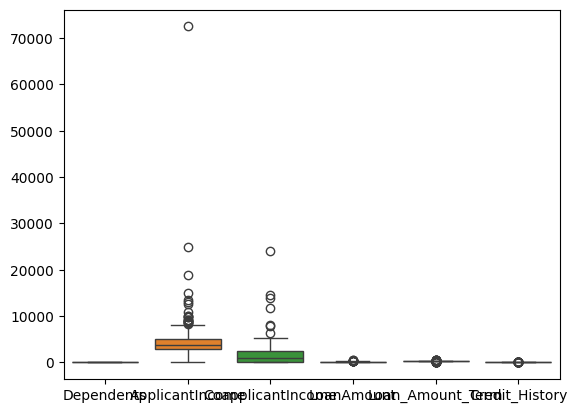

In [139]:
sns.boxplot(test_data)

#Encoding:

In [140]:
pd.get_dummies(test_data,drop_first=True).replace([True,False],[1,0])

/tmp/ipykernel_527/2019961008.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  pd.get_dummies(test_data,drop_first=True).replace([True,False],[1,0])


,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,5720,0,110.0,360.0,1.0,1,1,0,0,0,1
1,1,3076,1500,126.0,360.0,1.0,1,1,0,0,0,1
2,2,5000,1800,208.0,360.0,1.0,1,1,0,0,0,1
4,0,3276,0,78.0,360.0,1.0,1,0,1,0,0,1
5,0,2165,3422,152.0,360.0,1.0,1,1,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
361,1,2269,2167,99.0,360.0,1.0,1,1,0,0,1,0
362,3,4009,1777,113.0,360.0,1.0,1,1,1,1,0,1
363,0,4158,709,115.0,360.0,1.0,1,1,0,0,0,1
365,0,5000,2393,158.0,360.0,1.0,1,1,0,0,0,0


In [141]:
test_data=pd.get_dummies(test_data,drop_first=True).replace([True,False],[1,0])

/tmp/ipykernel_527/273633680.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_data=pd.get_dummies(test_data,drop_first=True).replace([True,False],[1,0])


In [142]:
test_data.head()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,5720,0,110.0,360.0,1.0,1,1,0,0,0,1
1,1,3076,1500,126.0,360.0,1.0,1,1,0,0,0,1
2,2,5000,1800,208.0,360.0,1.0,1,1,0,0,0,1
4,0,3276,0,78.0,360.0,1.0,1,0,1,0,0,1
5,0,2165,3422,152.0,360.0,1.0,1,1,1,1,0,1


In [143]:
dtree.fit(x_train, y_train)

DecisionTreeClassifier()

In [144]:
dtree.predict(test_data)

array([1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 0])

In [145]:
res=dtree.predict(test_data)

In [146]:
res

array([1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 0])

In [147]:
test_data["LS_Predict"]=res

In [148]:
test_data

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,LS_Predict
0,0,5720,0,110.0,360.0,1.0,1,1,0,0,0,1,1
1,1,3076,1500,126.0,360.0,1.0,1,1,0,0,0,1,1
2,2,5000,1800,208.0,360.0,1.0,1,1,0,0,0,1,0
4,0,3276,0,78.0,360.0,1.0,1,0,1,0,0,1,1
5,0,2165,3422,152.0,360.0,1.0,1,1,1,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,1,2269,2167,99.0,360.0,1.0,1,1,0,0,1,0,1
362,3,4009,1777,113.0,360.0,1.0,1,1,1,1,0,1,1
363,0,4158,709,115.0,360.0,1.0,1,1,0,0,0,1,1
365,0,5000,2393,158.0,360.0,1.0,1,1,0,0,0,0,0


#18)Conclusion:

In this project, a machine learning model using DecisionTreeClassifier was developed to predict loan approval based on applicant details such as income, education, employment status, credit history, and property area. The dataset was divided into training and testing data to build and evaluate the model.

Using AutoML and the DecisionTreeClassifier with a random state of 257, the model achieved a score of 91%. Evaluating the model with accuracy score gave a final accuracy of 95%, showing that the model can effectively predict loan approval status.

This system can help banks and financial institutions make faster and more accurate loan decisions. It reduces manual work and improves the efficiency of the loan approval process. In the future, using more data and advanced models can further improve prediction performance.